优化后CSV文件已生成：housing_price.csv


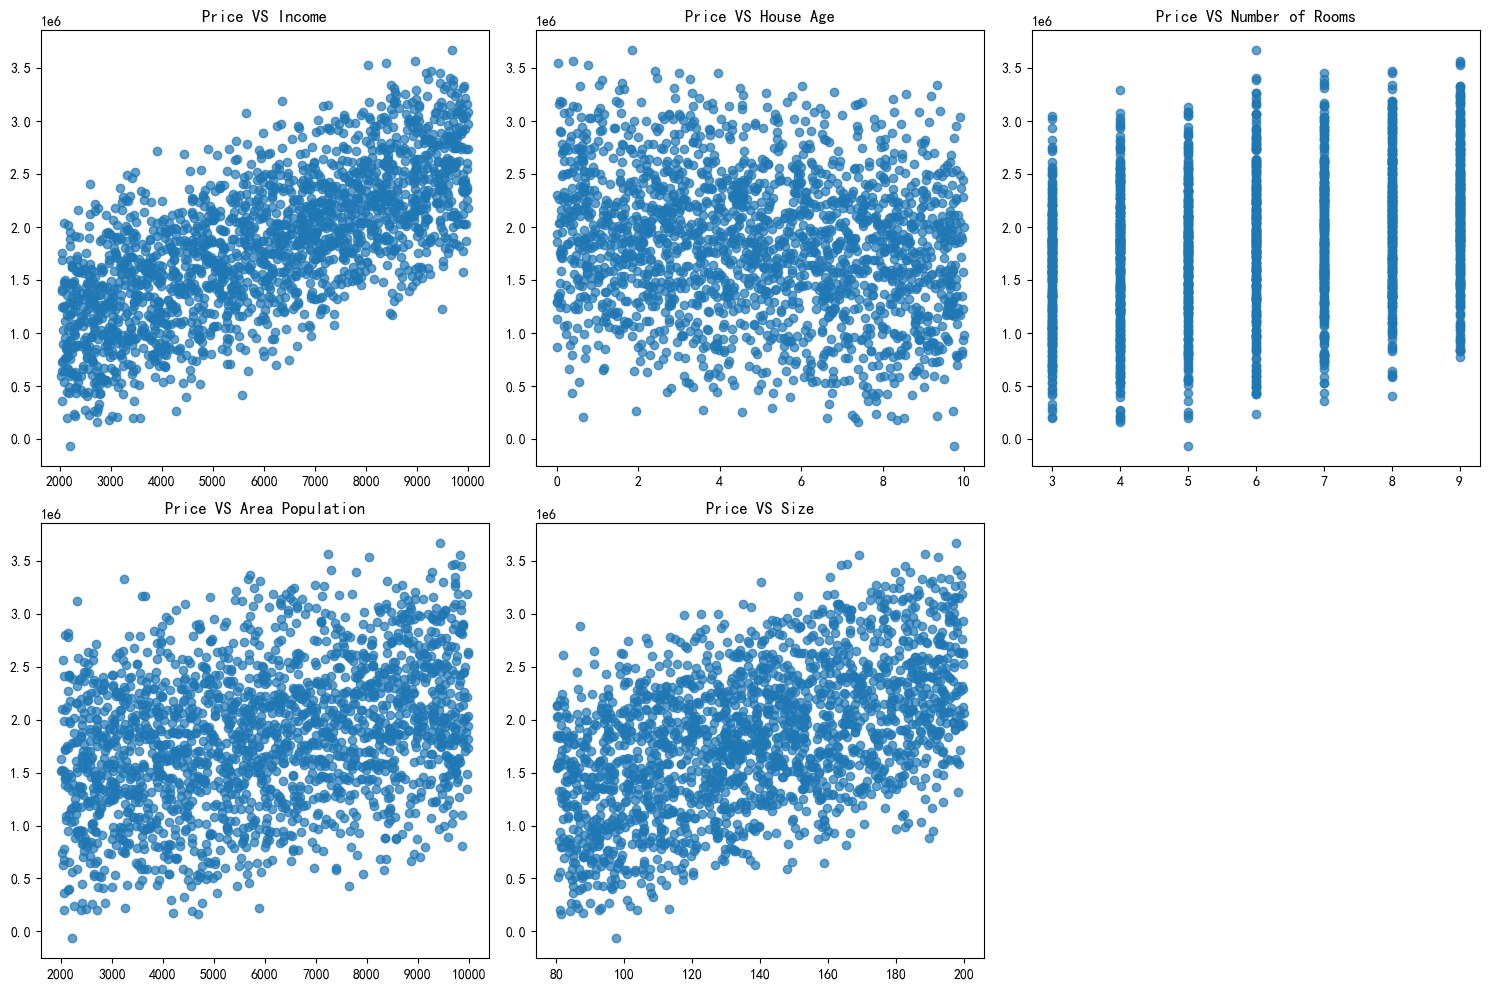

In [68]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 设置随机种子（保证结果可复现）
np.random.seed(42)

# 样本数量
n_samples = 2000

# 模拟各因子（范围与目标图匹配）
avg_area_income = np.random.uniform(2000, 10000, n_samples)       # 收入范围：2000~10000
avg_area_house_age = np.random.uniform(0, 10, n_samples)         # 房龄范围：0~10（匹配视频范围）
avg_area_number_of_rooms = np.random.randint(3, 10, n_samples)   # 房间数范围：3~9
area_population = np.random.uniform(2000, 10000, n_samples)      # 区域人口范围：2000~10000
size = np.random.uniform(80, 200, n_samples)                     # 面积范围：50~200

# 增强单因子线性趋势：增大回归系数 + 调整噪声至“适中”
intercept = 500000   # 基础房价（提升整体房价范围，匹配视频y轴）
beta_income = 200    # 收入对房价的正影响（显著增强）
beta_house_age = -50000  # 房龄对房价的负影响（显著增强）
beta_rooms = 100000  # 房间数对房价的正影响（显著增强）
beta_population = 100  # 区域人口对房价的正影响（显著增强）
beta_size = 10000    # 面积对房价的正影响（显著增强）
noise = np.random.normal(0, 15000, n_samples)  # 适中噪声（让点分散但不破坏趋势）

# 计算房价（线性组合 + 噪声）
price = (
    intercept +
    beta_income * avg_area_income +
    beta_house_age * avg_area_house_age +
    beta_rooms * avg_area_number_of_rooms +
    beta_population * area_population +
    beta_size * size +
    noise-2200000
)

# 组织成DataFrame并保存为CSV
data = pd.DataFrame({
    "Avg. Area Income": avg_area_income,
    "Avg. Area House Age": avg_area_house_age,
    "Avg. Area Number of Rooms": avg_area_number_of_rooms,
    "Area Population": area_population,
    "size": size,
    "Price": price
})
data.to_csv("housing_price.csv", index=False)
print("优化后CSV文件已生成：housing_price.csv")

# 绘制散点图验证效果
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Price VS Income
axes[0, 0].scatter(data["Avg. Area Income"], data["Price"], alpha=0.7)
axes[0, 0].set_title("Price VS Income")


# Price VS House Age
axes[0, 1].scatter(data["Avg. Area House Age"], data["Price"], alpha=0.7)
axes[0, 1].set_title("Price VS House Age")


# Price VS Number of Rooms
axes[0, 2].scatter(data["Avg. Area Number of Rooms"], data["Price"], alpha=0.7)
axes[0, 2].set_title("Price VS Number of Rooms")


# Price VS Area Population
axes[1, 0].scatter(data["Area Population"], data["Price"], alpha=0.7)
axes[1, 0].set_title("Price VS Area Population")


# Price VS Size
axes[1, 1].scatter(data["size"], data["Price"], alpha=0.7)
axes[1, 1].set_title("Price VS Size")


# 隐藏多余子图
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()
